<a href="https://colab.research.google.com/github/unidari/ml/blob/main/ml_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# **Практическая работа №5. Линейная и логистическая регрессия**



## **Линейная регрессия**



### **Задание №1. Прогнозирование продаж автомобилей**

- **Шаг 1**: Загрузите набор данных о продажах автомобилей, содержащий информацию о цене, возрасте, пробеге и других характеристиках.
  - **Совет №1**: Проверьте данные на наличие пропущенных значений и выбросов. Используйте `pandas` для обнаружения пропусков (`df.isnull().sum()`) и выбросов (например, с помощью метода межквартильного размаха - `df.boxplot()`).
  - **Совет №2**: Для пропущенных значений используйте стратегию заполнения средними значениями или медианой, чтобы минимизировать влияние на распределение данных (`df.fillna()`).




- Ссылка на набор данных: https://www.kaggle.com/datasets/gagandeep16/car-sales

In [45]:
import pandas as pd
import kagglehub

kagglehub.dataset_download("gagandeep16/car-sales")

data = pd.read_csv('/kaggle/input/car-sales/Car_sales.csv')
display(data.dtypes)
data.head(10)

Using Colab cache for faster access to the 'car-sales' dataset.


,0
Manufacturer,object
Model,object
Sales_in_thousands,float64
__year_resale_value,float64
Vehicle_type,object
Price_in_thousands,float64
Engine_size,float64
Horsepower,float64
Wheelbase,float64
Width,float64


,Manufacturer,Model,Sales_in_thousands,__year_resale_value,Vehicle_type,Price_in_thousands,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,Fuel_efficiency,Latest_Launch,Power_perf_factor
0,Acura,Integra,16.919,16.360,Passenger,21.50,1.8,140.0,101.2,67.3,172.4,2.639,13.2,28.0,2/2/2012,58.280150
1,Acura,TL,39.384,19.875,Passenger,28.40,3.2,225.0,108.1,70.3,192.9,3.517,17.2,25.0,6/3/2011,91.370778
2,Acura,CL,14.114,18.225,Passenger,NaN,3.2,225.0,106.9,70.6,192.0,3.470,17.2,26.0,1/4/2012,NaN
3,Acura,RL,8.588,29.725,Passenger,42.00,3.5,210.0,114.6,71.4,196.6,3.850,18.0,22.0,3/10/2011,91.389779
4,Audi,A4,20.397,22.255,Passenger,23.99,1.8,150.0,102.6,68.2,178.0,2.998,16.4,27.0,10/8/2011,62.777639
5,Audi,A6,18.780,23.555,Passenger,33.95,2.8,200.0,108.7,76.1,192.0,3.561,18.5,22.0,8/9/2011,84.565105
6,Audi,A8,1.380,39.000,Passenger,62.00,4.2,310.0,113.0,74.0,198.2,3.902,23.7,21.0,2/27/2012,134.656858
7,BMW,323i,19.747,NaN,Passenger,26.99,2.5,170.0,107.3,68.4,176.0,3.179,16.6,26.0,6/28/2011,71.191207
8,BMW,328i,9.231,28.675,Passenger,33.40,2.8,193.0,107.3,68.5,176.0,3.197,16.6,24.0,1/29/2012,81.877069
9,BMW,528i,17.527,36.125,Passenger,38.90,2.8,193.0,111.4,70.9,188.0,3.472,18.5,25.0,4/4/2011,83.998724


,0
Manufacturer,0
Model,0
Sales_in_thousands,0
__year_resale_value,36
Vehicle_type,0
Price_in_thousands,2
Engine_size,1
Horsepower,1
Wheelbase,1
Width,1


<Axes: >

,Sales_in_thousands,__year_resale_value,Price_in_thousands,Engine_size,Horsepower,Wheelbase,Width,Length,Curb_weight,Fuel_capacity,...,Model_Town car,Model_V40,Model_V70,Model_Villager,Model_Viper,Model_Voyager,Model_Windstar,Model_Wrangler,Model_Xterra,Vehicle_type_Passenger
0,16.919,16.360,21.500000,1.8,140.0,101.2,67.3,172.4,2.639,13.2,...,False,False,False,False,False,False,False,False,False,True
1,39.384,19.875,28.400000,3.2,225.0,108.1,70.3,192.9,3.517,17.2,...,False,False,False,False,False,False,False,False,False,True
2,14.114,18.225,27.390755,3.2,225.0,106.9,70.6,192.0,3.470,17.2,...,False,False,False,False,False,False,False,False,False,True
3,8.588,29.725,42.000000,3.5,210.0,114.6,71.4,196.6,3.850,18.0,...,False,False,False,False,False,False,False,False,False,True
4,20.397,22.255,23.990000,1.8,150.0,102.6,68.2,178.0,2.998,16.4,...,False,False,False,False,False,False,False,False,False,True


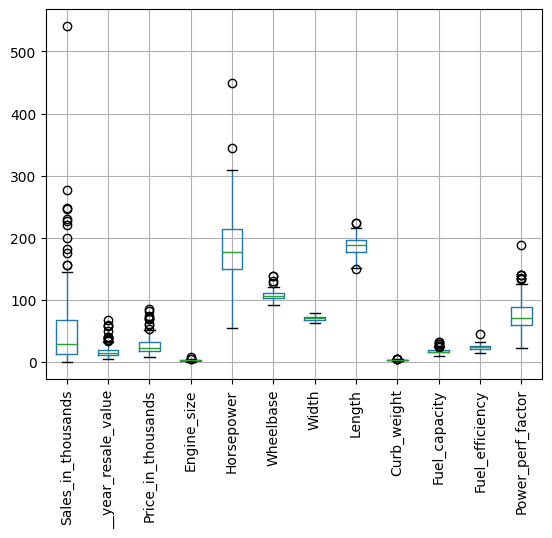

In [46]:
display(data.isnull().sum())
display(data.boxplot(rot=90))

columns = ['Manufacturer', 'Latest_Launch', 'Model', 'Vehicle_type']
data = pd.get_dummies(data, columns=columns, drop_first=True)

data.fillna(data.mean(), inplace=True)

data.head()

- **Шаг 2**: Проведите предварительный анализ данных:
  - Постройте гистограммы для каждого числового признака, чтобы понять их распределение.
  - Постройте диаграммы рассеяния для выявления зависимостей между признаками и целевой переменной (ценой).
  - **Совет**: Используйте корреляционную матрицу для выявления сильных линейных зависимостей между признаками.

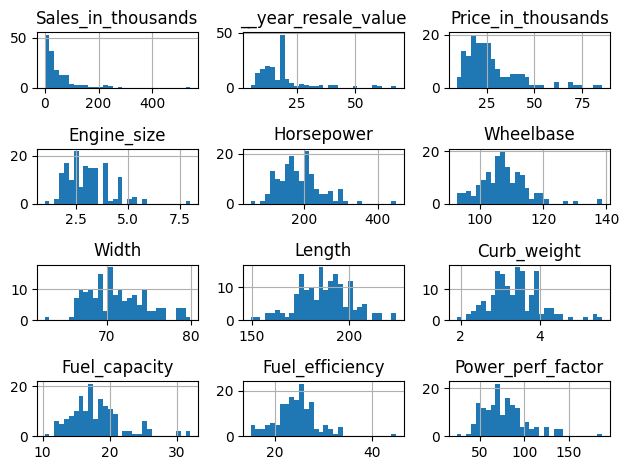

In [47]:
import matplotlib.pyplot as plt

data.select_dtypes(include='number').hist(bins=30)
plt.tight_layout()

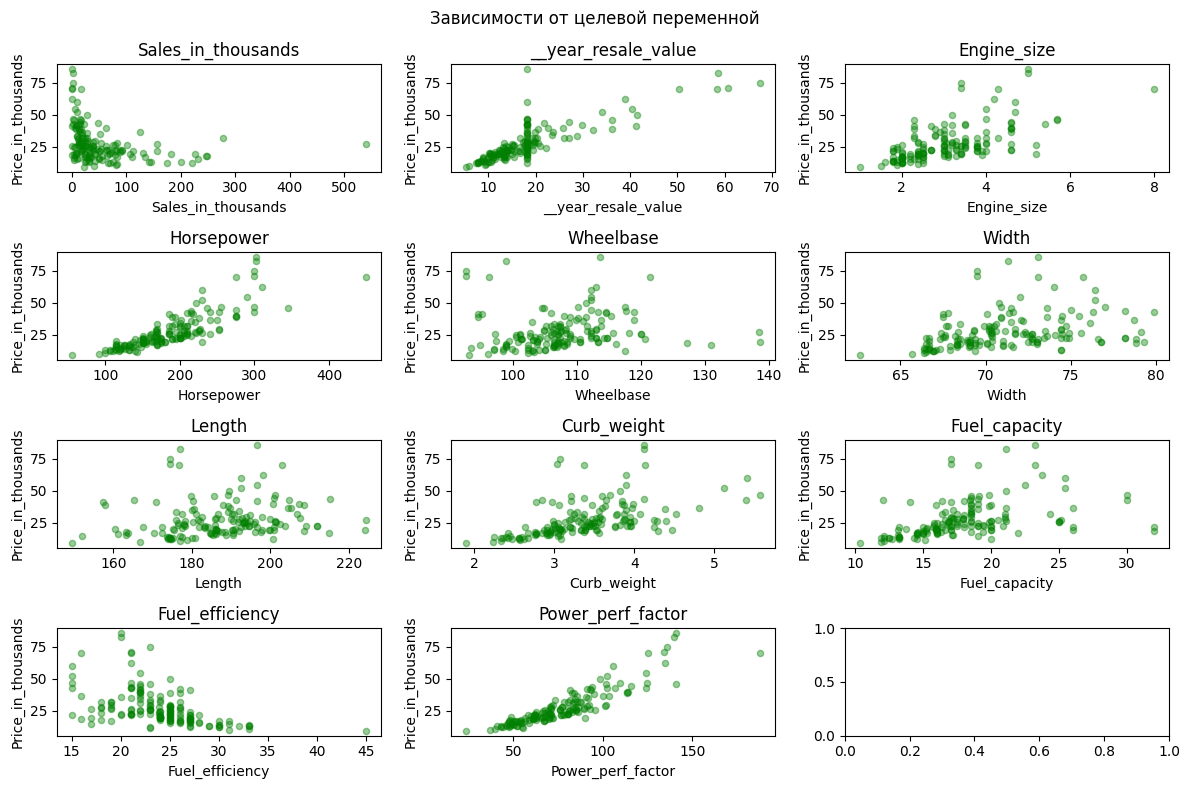

In [48]:
import matplotlib.pyplot as plt

target = 'Price_in_thousands'
features = data.select_dtypes(include='number').columns.drop('Price_in_thousands')
fig, axes = plt.subplots(4, 3, figsize=(12, 8))
axes = axes.flatten()

for ax, col in zip(axes, features):
    data.plot.scatter(x=col, y=target, color='green', ax=ax, alpha=0.4, s=20)
    ax.set_title(f'{col}')

plt.suptitle('Зависимости от целевой переменной')
plt.tight_layout()
plt.show()

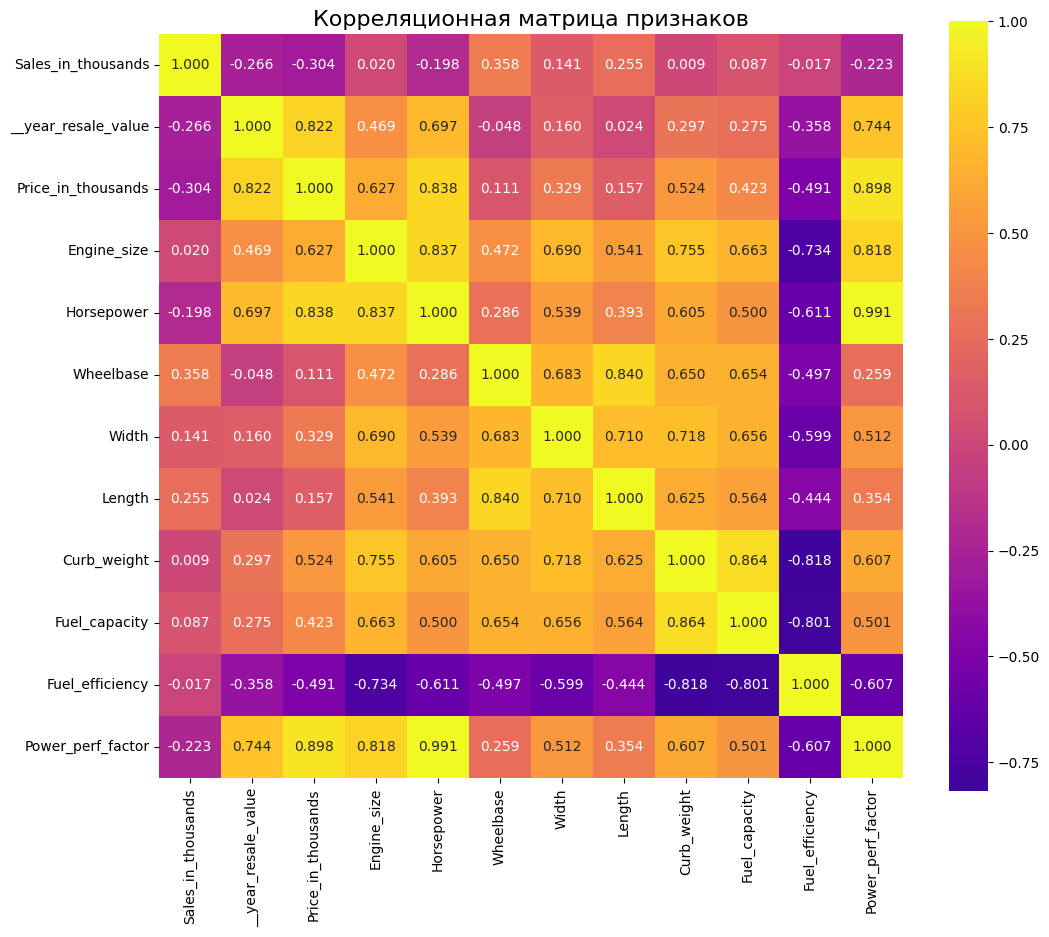

In [49]:
import seaborn as sns

corr = data.select_dtypes(include='number').corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr,
            annot=True,
            fmt='.3f',
            cmap='plasma',
            center=0,
            square=True)

plt.title('Корреляционная матрица признаков', fontsize=16)
plt.show()

- **Шаг 3**: Разделите данные на обучающую и тестовую выборки (например, 70% на обучение и 30% на тестирование) с помощью `train_test_split` из `sklearn.model_selection`.

In [50]:
from sklearn.model_selection import train_test_split

X = data.drop('Price_in_thousands', axis=1)
y = data['Price_in_thousands']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print(X_train.shape, X_test.shape)

(109, 325) (48, 325)


- **Шаг 4**: Постройте и обучите модели линейной регрессии с различными типами регуляризации:
  - Обучите базовую модель `LinearRegression` (без регуляризации).
  - Обучите модель **Ridge** (L2-регуляризация) с подбором гиперпараметра `alpha` с помощью `GridSearchCV`.
  - Обучите модель **Lasso** (L1-регуляризация) с подбором гиперпараметра `alpha` с помощью `RandomizedSearchCV`.
  - Обучите модель **ElasticNet** (комбинация L1 и L2) с подбором гиперпараметров `alpha` и `l1_ratio` с помощью `GridSearchCV` и/или `RandomizedSearchCV`.
  - **Совет**: Используйте `np.logspace(-4, 4, 50)` для генерации сетки значений `alpha`.



In [51]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import numpy as np

model = LinearRegression()
model.fit(X_train, y_train)

ridge = Ridge(random_state=42)
lasso = Lasso(random_state=42)
elast = ElasticNet(random_state=42)

param_ridge = {'alpha': np.logspace(-4, 4, 50)}
param_lasso = {'alpha': np.logspace(-4, 4, 50)}
param_elnet = {'alpha': np.logspace(-4, 4, 50), 'l1_ratio': np.linspace(0.001, 0.99, 20)}

grid_ridge = GridSearchCV(ridge, param_ridge, cv=5, n_jobs=-1)
grid_ridge.fit(X_train, y_train)

random_lasso = RandomizedSearchCV(lasso, param_lasso, cv=5, n_jobs=-1, random_state=42)
random_lasso.fit(X_train, y_train)

grid_elnet = GridSearchCV(elast, param_elnet, cv=5, n_jobs=-1)
grid_elnet.fit(X_train, y_train)

models = {
    'LinearRegression': model,
    'Ridge': grid_ridge.best_estimator_,
    'Lasso': random_lasso.best_estimator_,
    'ElasticNet': grid_elnet.best_estimator_
}

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.429e+01, tolerance: 1.735e+00
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.559e+01, tolerance: 1.735e+00
  model = cd_fast.enet_coordinate_descent(


- **Шаг 5**: Оцените качество всех моделей с использованием метрик MSE, RMSE, MAE и R².
  - Выведите значения метрик для каждой модели и интерпретируйте их.


In [52]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

metrics = {}
predictions = {}

for name, model in models.items():
    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    metrics[name] = {'MSE': mse, 'RMSE': rmse, 'MAE':mae, 'R²': r2}
    predictions[name] = (y_pred)

results_data = pd.DataFrame(metrics).T
display(results_data.round(4))

,MSE,RMSE,MAE,R²
LinearRegression,8.8630,2.9771,2.0399,0.9691
Ridge,5.6537,2.3777,1.7006,0.9803
Lasso,19.3226,4.3957,1.0932,0.9326
ElasticNet,4.9131,2.2166,0.5358,0.9829


- **Шаг 6**: Визуализируйте результаты:
  - Постройте график зависимости предсказанных цен от фактических для каждой модели.



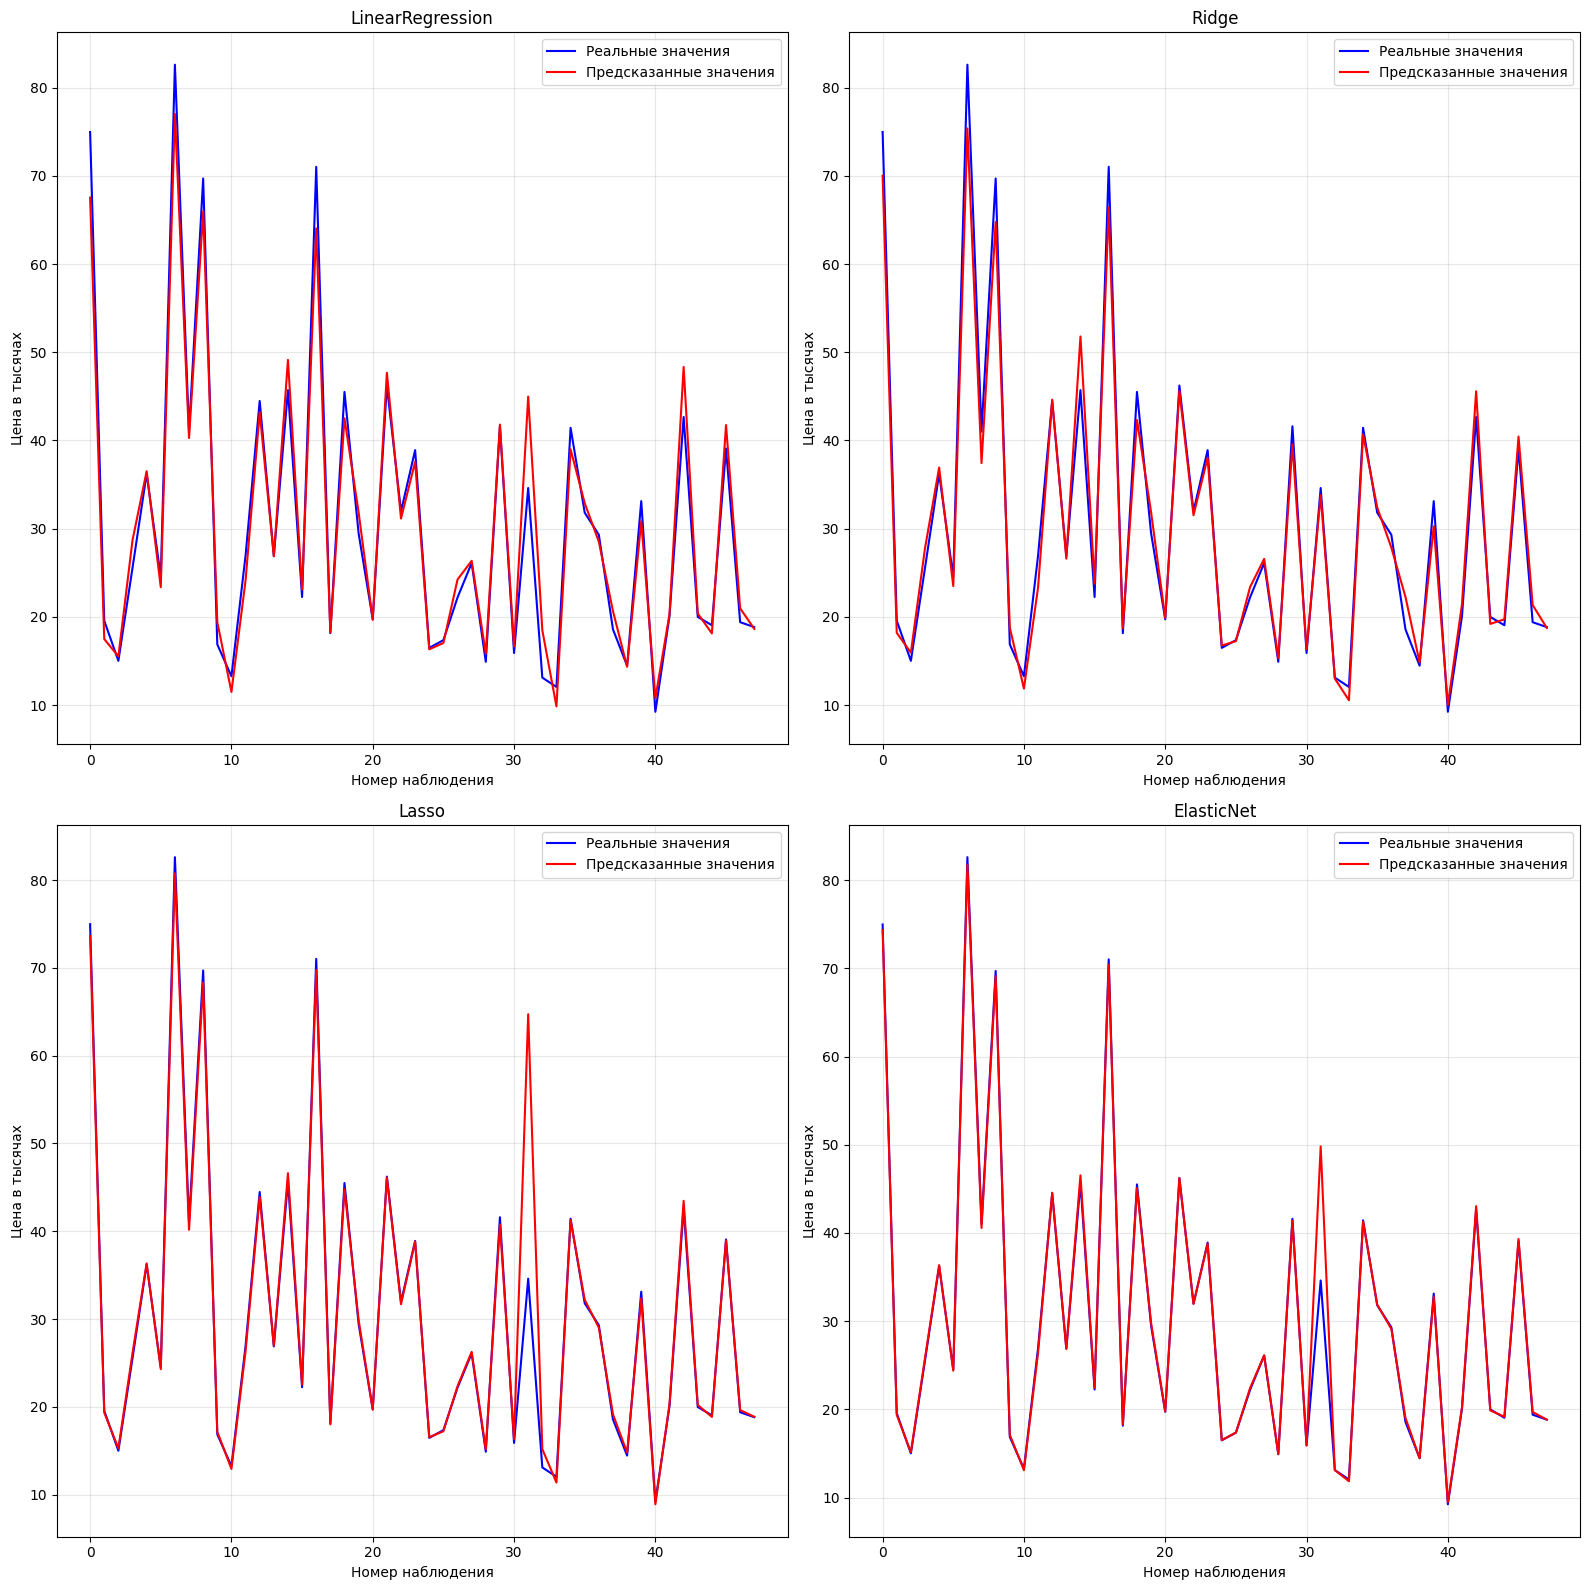

In [53]:
real = y_test.values

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 16))

for i, name in enumerate(predictions.keys()):
    row = i // 2
    col = i % 2
    axes[row, col].plot(real, label='Реальные значения', color='blue')
    axes[row, col].plot(predictions[name], label='Предсказанные значения', color='red')
    axes[row, col].set_title(name)
    axes[row, col].set_xlabel('Номер наблюдения')
    axes[row, col].set_ylabel('Цена в тысячах')
    axes[row, col].legend()
    axes[row, col].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



- **Шаг 7**: **Сравните все модели между собой по целевым метрикам (MSE, RMSE, MAE, R²)**:
  - Создайте сводную таблицу с метриками для всех моделей.
  - Определите лучшую модель и выведите для неё все метрики, а также оптимальные гиперпараметры.


In [54]:
df = pd.DataFrame.from_dict(metrics, orient='index').sort_values('R²', ascending=False)
display(df)

best_model_name = df.iloc[0].name
print(f'Лучшая модель: {best_model_name}')
print('Гиперпараметры:', models[best_model_name].get_params())

,MSE,RMSE,MAE,R²
ElasticNet,4.913109,2.216553,0.535794,0.982861
Ridge,5.653679,2.377747,1.700587,0.980278
LinearRegression,8.863044,2.977086,2.039871,0.969083
Lasso,19.322573,4.395745,1.093177,0.932597


Лучшая модель: ElasticNet
Гиперпараметры: {'alpha': np.float64(0.02811768697974228), 'copy_X': True, 'fit_intercept': True, 'l1_ratio': np.float64(0.99), 'max_iter': 1000, 'positive': False, 'precompute': False, 'random_state': 42, 'selection': 'cyclic', 'tol': 0.0001, 'warm_start': False}


---



### **Задание №2. Влияние погодных условий на урожайность**




- **Шаг 1**: Загрузите набор данных о погодных условиях и урожайности сельскохозяйственных культур.
  - **Совет**: Проверьте данные на наличие пропущенных значений и выбросов. Используйте стратегию заполнения пропусков средними значениями или медианой.

- Ссылка на набор данных: https://www.kaggle.com/datasets/waqi786/climate-change-impact-on-agriculture


In [55]:
import pandas as pd
import kagglehub

kagglehub.dataset_download("waqi786/climate-change-impact-on-agriculture")

data2 = pd.read_csv('/kaggle/input/climate-change-impact-on-agriculture/climate_change_impact_on_agriculture_2024.csv')
display(data2.dtypes)
data2.head(10)

Using Colab cache for faster access to the 'climate-change-impact-on-agriculture' dataset.


,0
Year,int64
Country,object
Region,object
Crop_Type,object
Average_Temperature_C,float64
Total_Precipitation_mm,float64
CO2_Emissions_MT,float64
Crop_Yield_MT_per_HA,float64
Extreme_Weather_Events,int64
Irrigation_Access_%,float64


,Year,Country,Region,Crop_Type,Average_Temperature_C,Total_Precipitation_mm,CO2_Emissions_MT,Crop_Yield_MT_per_HA,Extreme_Weather_Events,Irrigation_Access_%,Pesticide_Use_KG_per_HA,Fertilizer_Use_KG_per_HA,Soil_Health_Index,Adaptation_Strategies,Economic_Impact_Million_USD
0,2001,India,West Bengal,Corn,1.55,447.06,15.22,1.737,8,14.54,10.08,14.78,83.25,Water Management,808.13
1,2024,China,North,Corn,3.23,2913.57,29.82,1.737,8,11.05,33.06,23.25,54.02,Crop Rotation,616.22
2,2001,France,Ile-de-France,Wheat,21.11,1301.74,25.75,1.719,5,84.42,27.41,65.53,67.78,Water Management,796.96
3,2001,Canada,Prairies,Coffee,27.85,1154.36,13.91,3.890,5,94.06,14.38,87.58,91.39,No Adaptation,790.32
4,1998,India,Tamil Nadu,Sugarcane,2.19,1627.48,11.81,1.080,9,95.75,44.35,88.08,49.61,Crop Rotation,401.72
5,2019,USA,Midwest,Coffee,17.19,975.13,10.73,2.180,5,52.45,26.06,71.56,97.32,Water Management,353.16
6,1997,Argentina,Northeast,Fruits,23.46,1816.41,27.70,1.611,2,20.22,0.56,28.72,79.09,Organic Farming,480.61
7,2021,Australia,New South Wales,Rice,25.63,786.17,7.77,3.270,4,66.53,13.44,40.50,63.16,Drought-resistant Crops,1367.97
8,2012,India,Punjab,Wheat,32.08,1233.10,6.10,2.990,1,45.87,10.09,32.54,42.31,Water Management,761.89
9,2018,Nigeria,North West,Barley,21.23,475.32,25.74,0.765,1,25.74,44.38,72.92,84.21,No Adaptation,167.21


,0
Year,0
Country,0
Region,0
Crop_Type,0
Average_Temperature_C,0
Total_Precipitation_mm,0
CO2_Emissions_MT,0
Crop_Yield_MT_per_HA,0
Extreme_Weather_Events,0
Irrigation_Access_%,0


<Axes: >

,Year,Average_Temperature_C,Total_Precipitation_mm,CO2_Emissions_MT,Crop_Yield_MT_per_HA,Extreme_Weather_Events,Irrigation_Access_%,Pesticide_Use_KG_per_HA,Fertilizer_Use_KG_per_HA,Soil_Health_Index,...,Crop_Type_Fruits,Crop_Type_Rice,Crop_Type_Soybeans,Crop_Type_Sugarcane,Crop_Type_Vegetables,Crop_Type_Wheat,Adaptation_Strategies_Drought-resistant Crops,Adaptation_Strategies_No Adaptation,Adaptation_Strategies_Organic Farming,Adaptation_Strategies_Water Management
0,2001,1.55,447.06,15.22,1.737,8,14.54,10.08,14.78,83.25,...,False,False,False,False,False,False,False,False,False,True
1,2024,3.23,2913.57,29.82,1.737,8,11.05,33.06,23.25,54.02,...,False,False,False,False,False,False,False,False,False,False
2,2001,21.11,1301.74,25.75,1.719,5,84.42,27.41,65.53,67.78,...,False,False,False,False,False,True,False,False,False,True
3,2001,27.85,1154.36,13.91,3.890,5,94.06,14.38,87.58,91.39,...,False,False,False,False,False,False,False,True,False,False
4,1998,2.19,1627.48,11.81,1.080,9,95.75,44.35,88.08,49.61,...,False,False,False,True,False,False,False,False,False,False


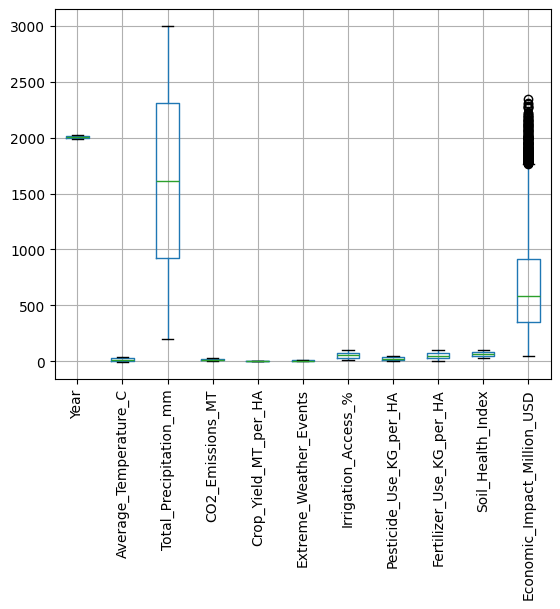

In [56]:
display(data2.isnull().sum())
display(data2.boxplot(rot=90))

columns = ['Country', 'Region', 'Crop_Type', 'Adaptation_Strategies']
data22 = pd.get_dummies(data2, columns=columns, drop_first=True)

data22.head()




- **Шаг 2**: Выполните анализ данных:
  - Постройте корреляционную матрицу для выявления зависимостей между признаками.
  - Постройте диаграммы рассеяния для ключевых признаков.
  - **Совет**: Удалите или преобразуйте признаки с низкой корреляцией с целевой переменной, чтобы улучшить модель.



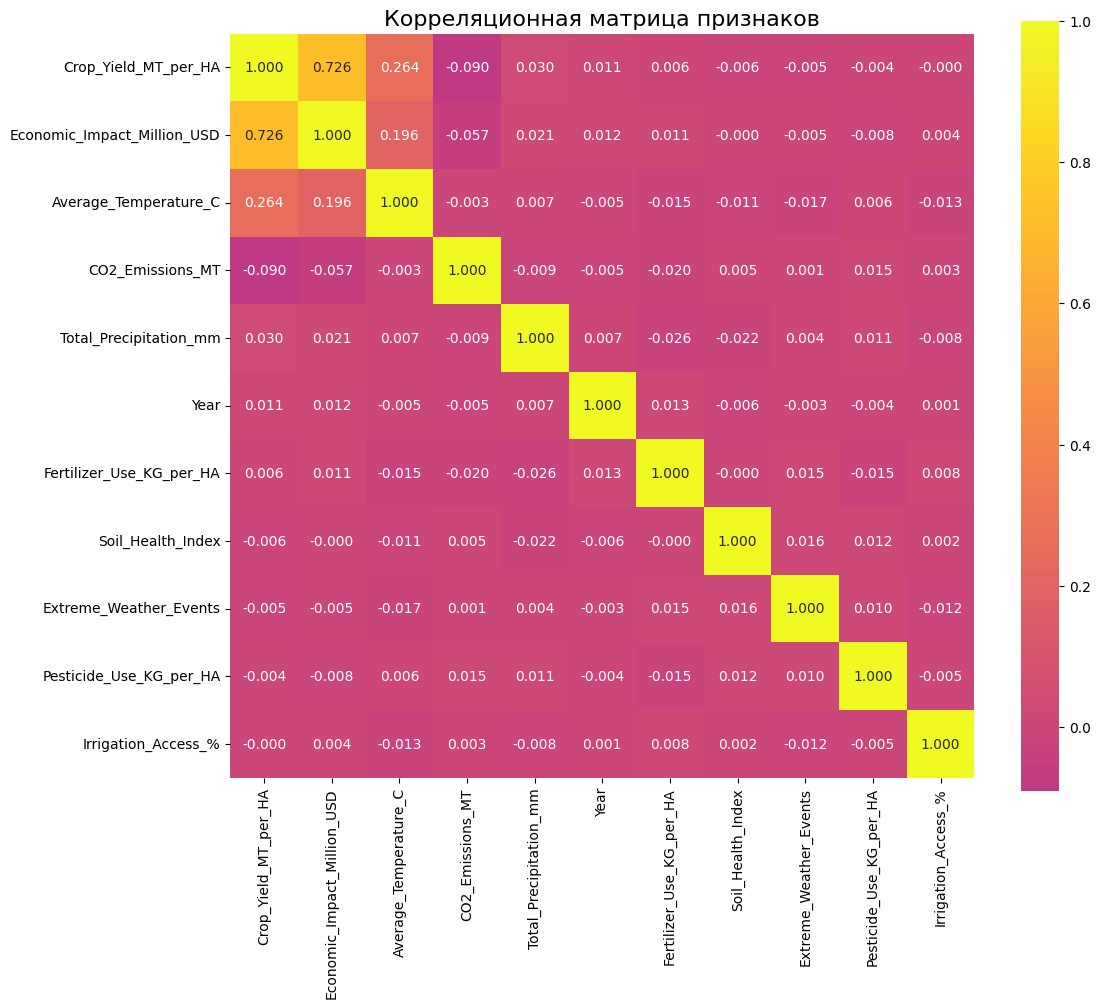

In [57]:
import seaborn as sns

corr = data22.select_dtypes(include='number').corr()
target = 'Crop_Yield_MT_per_HA'
top = corr[target].abs().sort_values(ascending=False).index

plt.figure(figsize=(12, 10))
sns.heatmap(corr.loc[top, top],
            annot=True,
            fmt='.3f',
            cmap='plasma',
            center=0,
            square=True)

plt.title('Корреляционная матрица признаков', fontsize=16)
plt.show()

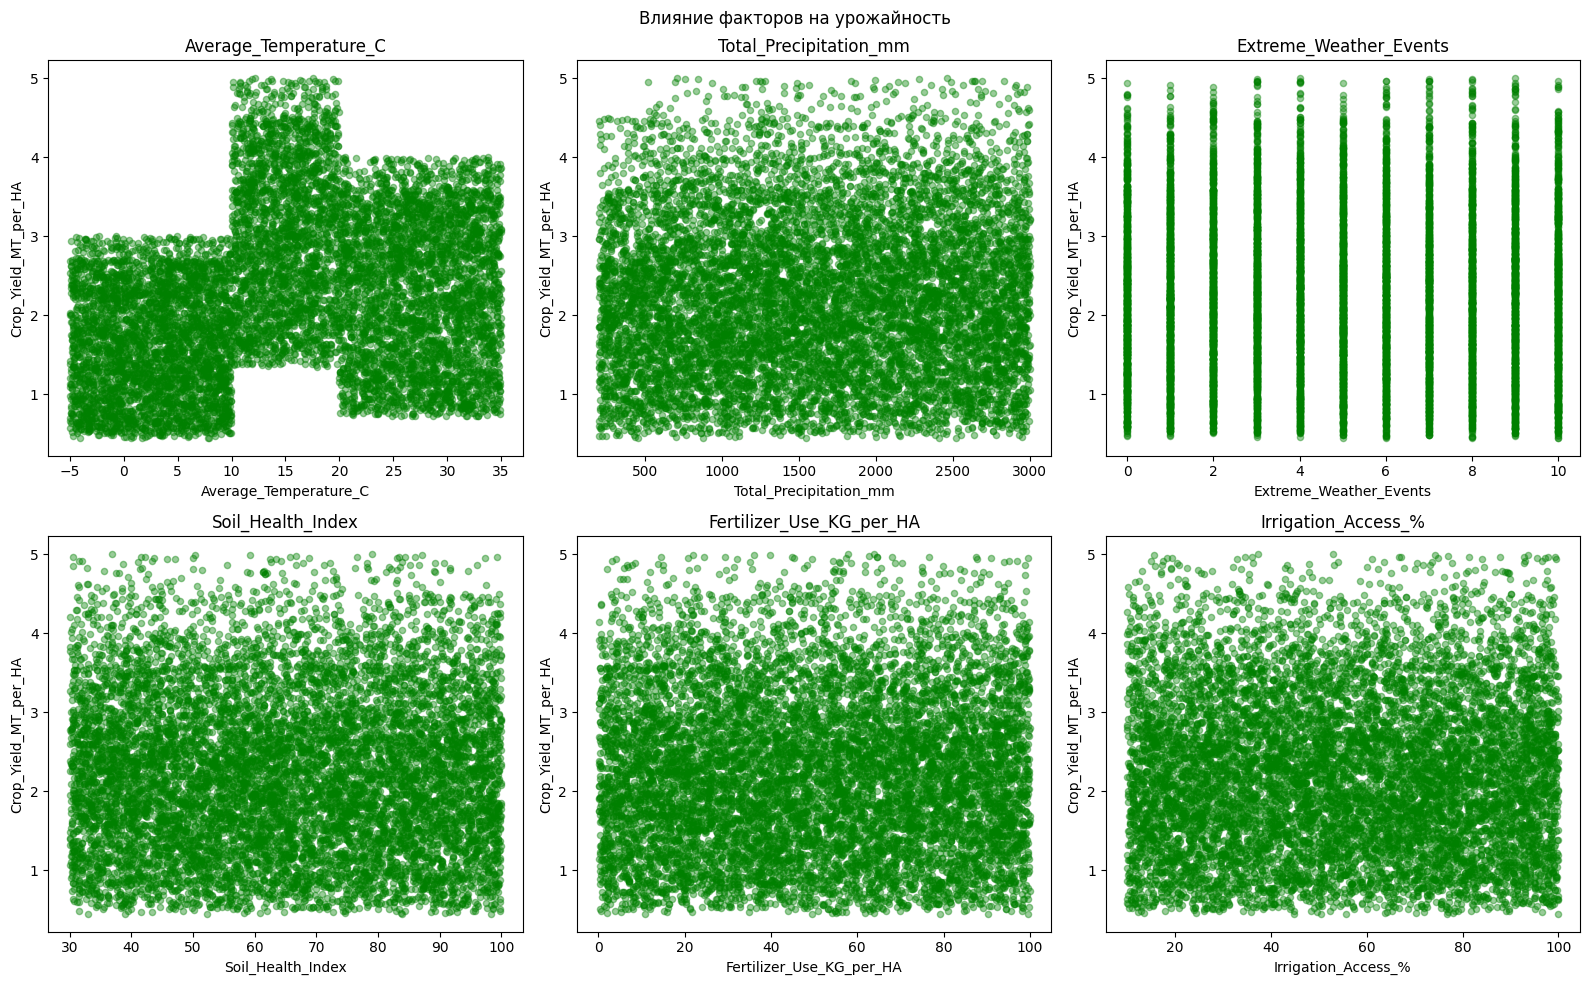

In [58]:
import matplotlib.pyplot as plt

target = 'Crop_Yield_MT_per_HA'
features = ['Average_Temperature_C', 'Total_Precipitation_mm', 'Extreme_Weather_Events', 'Soil_Health_Index', 'Fertilizer_Use_KG_per_HA', 'Irrigation_Access_%']
#'Средняя температура (°C)', 'Общее количество осадков (мм)', 'Экстремальные погодные явления', 'Индекс здоровья почвы', 'Использование удобрений (кг/га)', 'Доступ к орошению (%)'
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for ax, col in zip(axes, features):
    data22.plot.scatter(x=col, y=target, color='green', ax=ax, alpha=0.4, s=20)
    ax.set_title(f'{col}')

plt.suptitle('Влияние факторов на урожайность')
plt.tight_layout()
plt.show()

In [59]:
data_reduced = data2.drop(['Irrigation_Access_%',
                     'Year', 'Pesticide_Use_KG_per_HA',
                     'Fertilizer_Use_KG_per_HA', 'Soil_Health_Index',
                     'Economic_Impact_Million_USD',
                           'Country', 'Region', 'Crop_Type', 'Adaptation_Strategies'], axis=1)

- **Шаг 3**: Разделите данные на обучающую и тестовую выборки.

In [60]:
from sklearn.model_selection import train_test_split
X = data_reduced.drop('Crop_Yield_MT_per_HA', axis=1)
y = data_reduced['Crop_Yield_MT_per_HA']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
display(X_train.shape, X_test.shape)

(7000, 4)

(3000, 4)



- **Шаг 4**: Постройте и обучите модели линейной регрессии с различными типами регуляризации для оценки влияния температуры и уровня осадков на урожайность:
  - Обучите базовую модель `LinearRegression` (без регуляризации).
  - Обучите модель **Ridge** (L2-регуляризация) с подбором гиперпараметра `alpha` с помощью `RandomizedSearchCV`.
  - Обучите модель **Lasso** (L1-регуляризация) с подбором гиперпараметра `alpha` с помощью `GridSearchCV`.
  - Обучите модель **ElasticNet** с подбором гиперпараметров `alpha` и `l1_ratio` с помощью `GridSearchCV` и/или `RandomizedSearchCV` .

In [61]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import numpy as np

model = LinearRegression()
model.fit(X_train, y_train)

ridge = Ridge(random_state=42)
lasso = Lasso(random_state=42)
elast = ElasticNet(random_state=42)

param_ridge = {'alpha': np.logspace(-4, 4, 50)}
param_lasso = {'alpha': np.logspace(-4, 4, 50)}
param_elnet = {'alpha': np.logspace(-4, 4, 50), 'l1_ratio': np.linspace(0.001, 0.99, 20)}

random_ridge = RandomizedSearchCV(ridge, param_ridge, cv=5, n_jobs=-1, random_state=42)
random_ridge.fit(X_train, y_train)
grid_lasso = GridSearchCV(lasso, param_lasso, cv=5, n_jobs=-1)
grid_lasso.fit(X_train, y_train)
grid_elnet = GridSearchCV(elast, param_elnet, cv=5, n_jobs=-1)
grid_elnet.fit(X_train, y_train)

models2 = {
    'LinearRegression': model,
    'Ridge': random_ridge.best_estimator_,
    'Lasso': grid_lasso.best_estimator_,
    'ElasticNet': grid_elnet.best_estimator_
}

- **Шаг 5**: Проведите оценку точности всех моделей.
  - Выведите значения метрик MSE, RMSE, MAE и R² для каждой модели и интерпретируйте их.

In [62]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

metrics2 = {}
predictions2 = {}

for name, model in models2.items():
    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    metrics2[name] = {'MSE': mse, 'RMSE': rmse, 'MAE':mae, 'R²': r2}
    predictions2[name] = (y_pred)

results_data2 = pd.DataFrame(metrics2).T
display(results_data2.round(4))

,MSE,RMSE,MAE,R²
LinearRegression,0.9484,0.9739,0.7960,0.0688
Ridge,0.9483,0.9738,0.7961,0.0689
Lasso,0.9478,0.9736,0.7961,0.0693
ElasticNet,0.9478,0.9736,0.7961,0.0693




- **Шаг 6**: Визуализируйте данные и результаты моделей:
  - Постройте графики зависимости предсказанных значений от фактических для каждой модели.

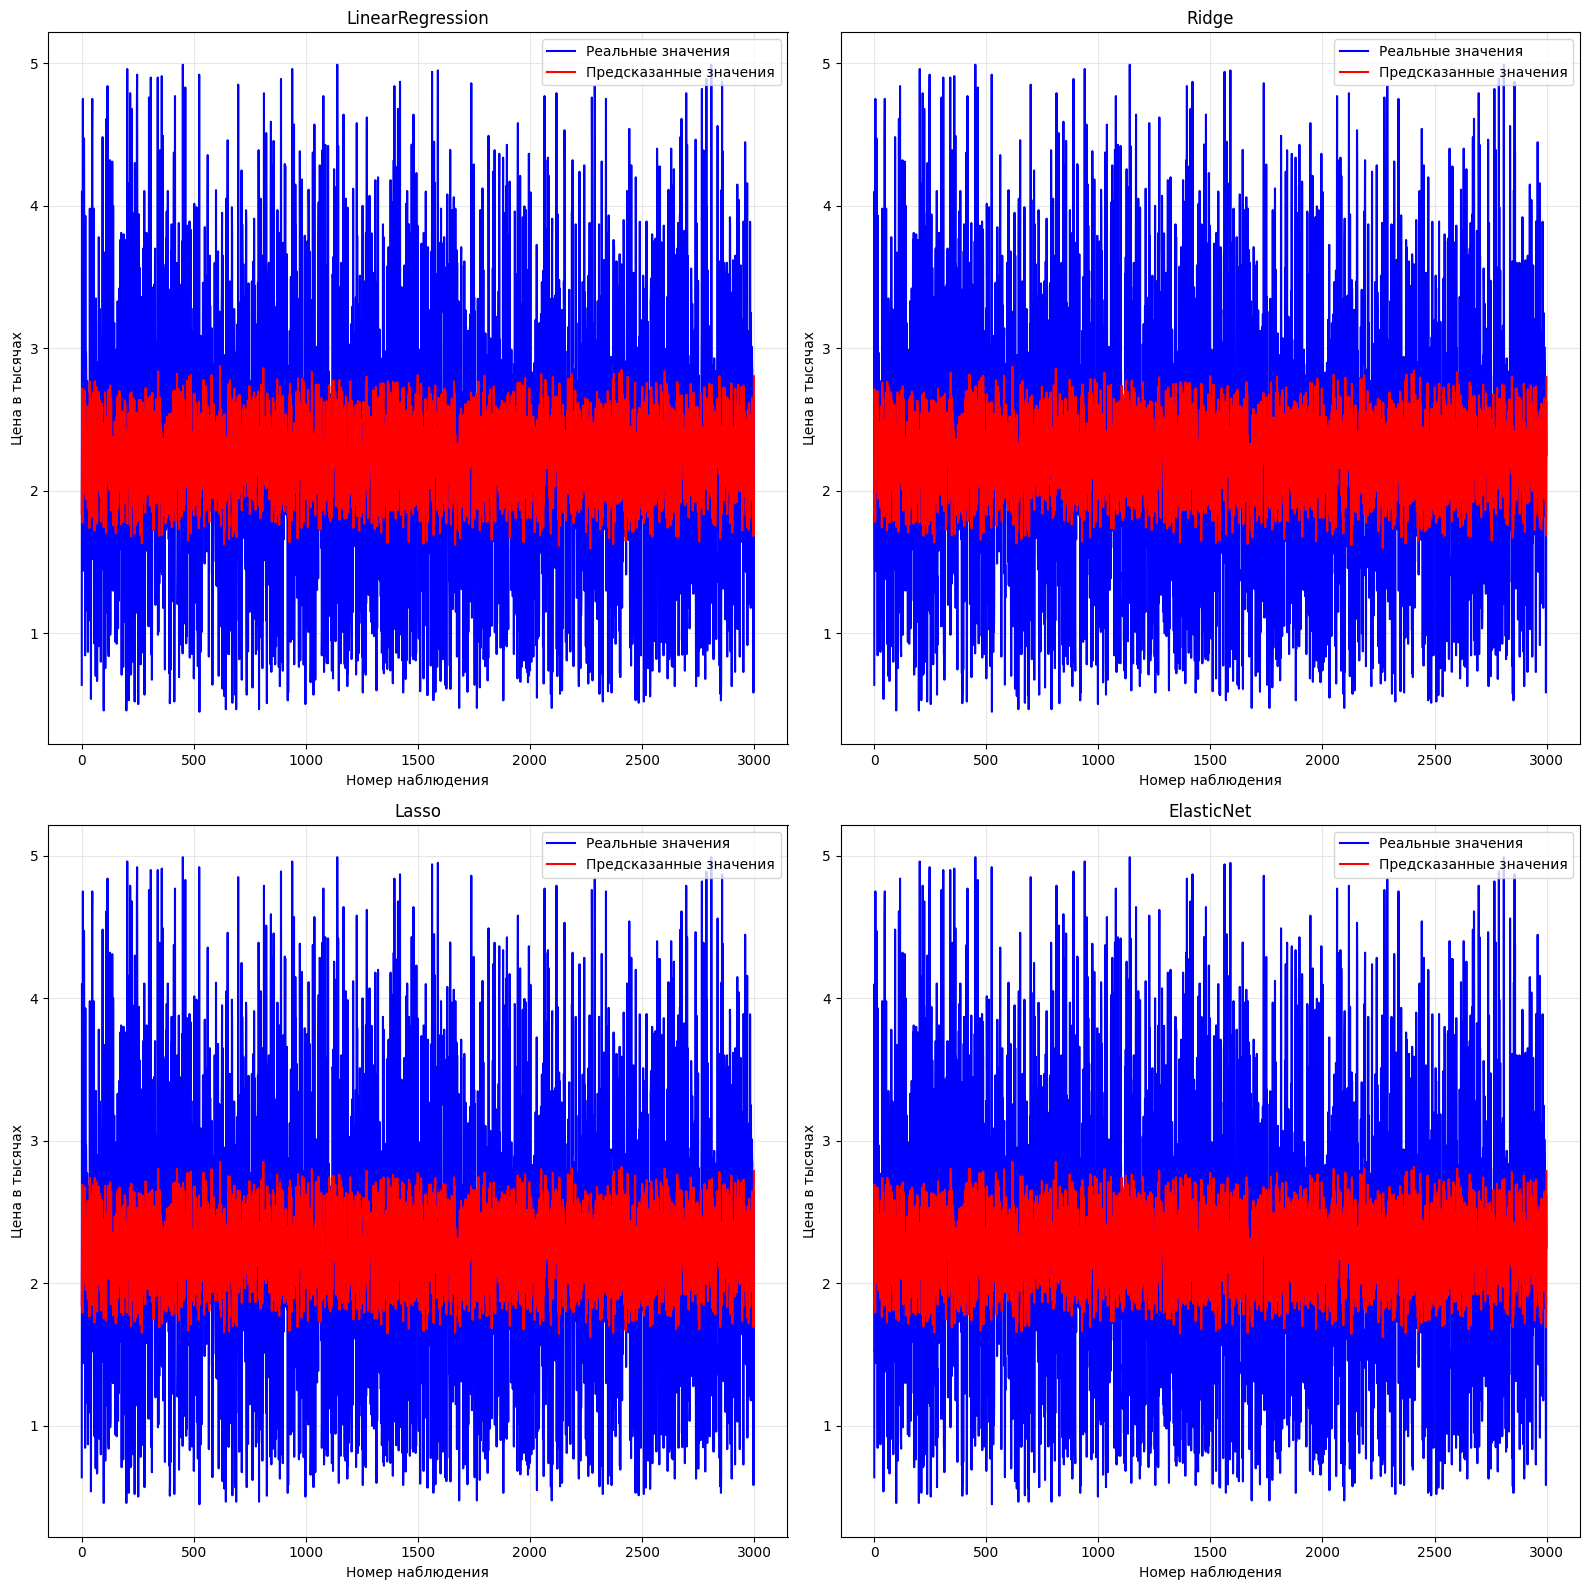

In [63]:
real2 = y_test.values

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 16))

for i, name in enumerate(predictions2.keys()):
    row = i // 2
    col = i % 2
    axes[row, col].plot(real2, label='Реальные значения', color='blue')
    axes[row, col].plot(predictions2[name], label='Предсказанные значения', color='red')
    axes[row, col].set_title(name)
    axes[row, col].set_xlabel('Номер наблюдения')
    axes[row, col].set_ylabel('Цена в тысячах')
    axes[row, col].legend()
    axes[row, col].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

- **Шаг 7**: **Сравните все модели между собой по целевым метрикам (MSE, RMSE, MAE, R²)**:
  - Создайте сводную таблицу с метриками для всех моделей.
  - Определите лучшую модель и выведите для неё все метрики, а также оптимальные гиперпараметры.

In [64]:
df2 = pd.DataFrame.from_dict(metrics2, orient='index').sort_values('R²', ascending=False)
display(df2)

best_model_name2 = df2.iloc[0].name
print(f'Лучшая модель: {best_model_name2}')
print('Гиперпараметры:', models2[best_model_name2].get_params())

,MSE,RMSE,MAE,R²
ElasticNet,0.947822,0.973561,0.796076,0.069340
Lasso,0.947824,0.973563,0.796079,0.069338
Ridge,0.948306,0.973810,0.796083,0.068865
LinearRegression,0.948405,0.973861,0.796040,0.068767


Лучшая модель: ElasticNet
Гиперпараметры: {'alpha': np.float64(0.05963623316594643), 'copy_X': True, 'fit_intercept': True, 'l1_ratio': np.float64(0.99), 'max_iter': 1000, 'positive': False, 'precompute': False, 'random_state': 42, 'selection': 'cyclic', 'tol': 0.0001, 'warm_start': False}


- **Шаг 8: Проанализируйте влияние признаков на урожайность**

  - На основе лучшей модели проведите анализ важности признаков:

    - Извлеките коэффициенты (`coef_`) лучшей модели и сопоставьте их с названиями признаков.
    - Визуализируйте важность признаков с помощью горизонтальной столбчатой диаграммы.
    - Проинтерпретируйте результаты: определите, какие погодные факторы (температура, осадки, CO₂ и др.) оказывают наибольшее положительное и отрицательное влияние на урожайность.
    - **Совет**: Для модели Lasso обратите внимание на признаки с нулевыми коэффициентами — они были исключены как незначимые.
    - **Совет**: Если данные были стандартизированы (`StandardScaler`), коэффициенты можно напрямую сравнивать по абсолютной величине для оценки относительной важности.



Average_Temperature_C: 0.0230
Total_Precipitation_mm: 0.0000
CO2_Emissions_MT: -0.0088
Extreme_Weather_Events: -0.0000


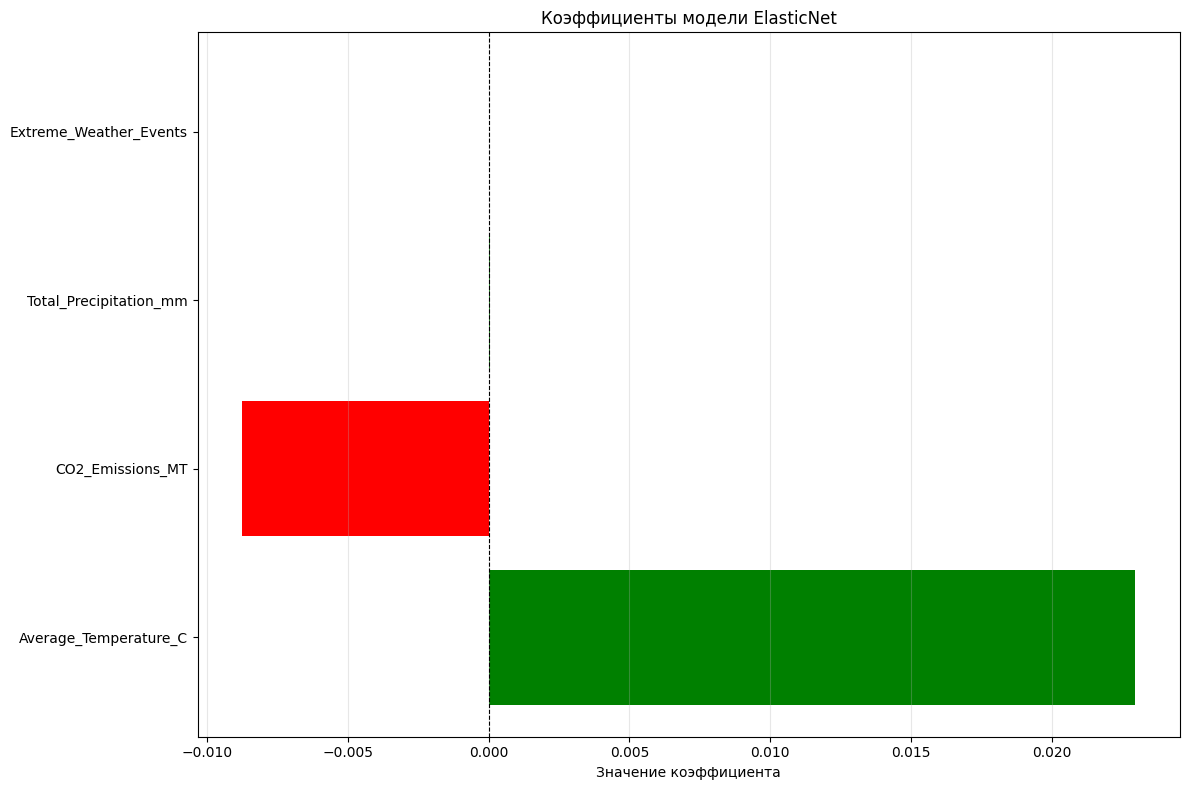

In [65]:
best_model2 = models2[best_model_name2]

coefs = []
cols = []

for idx, value in enumerate(best_model2.coef_):
    print(f"{X_train.columns[idx]}: {value:.4f}")
    cols.append(X_train.columns[idx])
    coefs.append(value)

sorted_idx = np.argsort(np.abs(coefs))[::-1]
cols_sorted = [cols[i] for i in sorted_idx]
coefs_sorted = [coefs[i] for i in sorted_idx]

colors = ['green' if c > 0 else 'red' for c in coefs_sorted]

plt.figure(figsize=(12, 8))
plt.barh(cols_sorted, coefs_sorted, color=colors)
plt.xlabel('Значение коэффициента')
plt.title(f'Коэффициенты модели {best_model_name2}')
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

#### **Интерпретация результатов (пример формулировки для отчёта):**


**[ТРЕБУЕТСЯ ЗАПОЛНИТЬ!]**


> На основе анализа коэффициентов лучшей модели установлено, что:
> - **Положительное влияние** на урожайность оказывают: Average_Temperature_C.
> - **Отрицательное влияние** на урожайность оказывают: CO2_Emissions_MT.
> - Наиболее значимым фактором является Average_Temperature_C с коэффициентом 0.0230, что означает: при увеличении данного показателя на 1 единицу (при прочих равных) урожайность изменяется на 0.0230 единиц.

---



## **Логистическая регрессия**



### **Задание №3. Классификация клиентов банка**

- **Шаг 1**: Загрузите набор данных о клиентах банка, включающий данные о возрасте, доходе, кредитной истории и других характеристиках.
  - **Совет**: Проверьте данные на наличие пропущенных значений и выбросов. Используйте стратегию заполнения пропусков средними значениями или медианой.



- Ссылка на набор данных: https://www.kaggle.com/datasets/henriqueyamahata/bank-marketing/data

In [66]:
import kagglehub
import pandas as pd

path = kagglehub.dataset_download("henriqueyamahata/bank-marketing")
data3 = pd.read_csv('/kaggle/input/bank-marketing/bank-additional-full.csv', sep=';')

data3.head()

Using Colab cache for faster access to the 'bank-marketing' dataset.


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0


<Axes: >

,0
age,int64
job,object
marital,object
education,object
default,object
housing,object
loan,object
contact,object
month,object
day_of_week,object


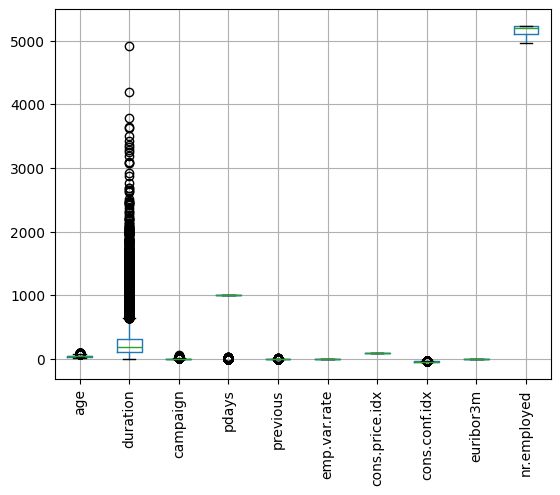

In [67]:
display(data3.isnull().sum())
display(data3.boxplot(rot=90))

display(data3.dtypes)

- **Шаг 2**: Проведите анализ данных и предобработку:
  - Закодируйте категориальные переменные с помощью `OneHotEncoder` или `pd.get_dummies`.
  - Нормализуйте числовые признаки с помощью `StandardScaler` для улучшения обучения модели.
  - **Совет**: Убедитесь, что все признаки имеют одинаковый масштаб, чтобы избежать доминирования одного признака над другими.

In [68]:
from sklearn.preprocessing import StandardScaler

num_cols = data3.select_dtypes(include='number').columns

scaler = StandardScaler()
data3[num_cols] = scaler.fit_transform(data3[num_cols])

data33 = pd.get_dummies(data3, data3.select_dtypes(include='object').columns, drop_first=True)
display(data33.columns)

print(data33[num_cols].describe())
print(data33[num_cols].std())

Index(['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed',
       'job_blue-collar', 'job_entrepreneur', 'job_housemaid',
       'job_management', 'job_retired', 'job_self-employed', 'job_services',
       'job_student', 'job_technician', 'job_unemployed', 'job_unknown',
       'marital_married', 'marital_single', 'marital_unknown',
       'education_basic.6y', 'education_basic.9y', 'education_high.school',
       'education_illiterate', 'education_professional.course',
       'education_university.degree', 'education_unknown', 'default_unknown',
       'default_yes', 'housing_unknown', 'housing_yes', 'loan_unknown',
       'loan_yes', 'contact_telephone', 'month_aug', 'month_dec', 'month_jul',
       'month_jun', 'month_mar', 'month_may', 'month_nov', 'month_oct',
       'month_sep', 'day_of_week_mon', 'day_of_week_thu', 'day_of_week_tue',
       'day_of_week_wed', 'poutcome_nonexistent', 'poutcome_s

                age      duration      campaign         pdays      previous  \
count  4.118800e+04  4.118800e+04  4.118800e+04  4.118800e+04  4.118800e+04   
mean  -1.880382e-16 -1.397348e-17 -7.590531e-17 -2.580781e-16  5.520386e-18   
std    1.000012e+00  1.000012e+00  1.000012e+00  1.000012e+00  1.000012e+00   
min   -2.209365e+00 -9.961775e-01 -5.659220e-01 -5.149443e+00 -3.494943e-01   
25%   -7.699804e-01 -6.027745e-01 -5.659220e-01  1.954139e-01 -3.494943e-01   
50%   -1.942267e-01 -3.019369e-01 -2.049085e-01  1.954139e-01 -3.494943e-01   
75%    6.694038e-01  2.341712e-01  1.561049e-01  1.954139e-01 -3.494943e-01   
max    5.563310e+00  1.797202e+01  1.928982e+01  1.954139e-01  1.379492e+01   

       emp.var.rate  cons.price.idx  cons.conf.idx     euribor3m   nr.employed  
count  4.118800e+04    4.118800e+04   4.118800e+04  41188.000000  4.118800e+04  
mean   7.797546e-17   -3.315820e-14  -1.352495e-16      0.000000 -1.024860e-14  
std    1.000012e+00    1.000012e+00   1.00001

- **Шаг 3**: Разделите данные на обучающую и тестовую выборки.

In [69]:
from sklearn.model_selection import train_test_split

X = data33.drop('y_yes', axis=1)
y = data33['y_yes']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

X_train.shape, X_test.shape

((28831, 53), (12357, 53))

- **Шаг 4**: Постройте и обучите модели логистической регрессии с различными типами регуляризации для предсказания вероятности открытия депозитного счета клиентом:
  - Обучите модель `LogisticRegression` с **L2-регуляризацией** (`penalty='l2'`) и подбором гиперпараметра `C` с помощью `GridSearchCV`.
  - Обучите модель `LogisticRegression` с **L1-регуляризацией** (`penalty='l1'`, `solver='saga'`) и подбором гиперпараметра `C` с помощью `RandomizedSearchCV`.
  - Обучите модель `LogisticRegression` с **ElasticNet-регуляризацией** (`penalty='elasticnet'`, `solver='saga'`) и подбором гиперпараметров `C` и `l1_ratio` с помощью `GridSearchCV` и/или `RandomizedSearchCV` .
  - **Совет**: Для L1 и ElasticNet используйте `solver='saga'`, так как он поддерживает оба типа регуляризации.


In [70]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import numpy as np

model_l2 = LogisticRegression(penalty='l2')
model_l1 = LogisticRegression(penalty='l1', solver='saga')
elnet = LogisticRegression(penalty='elasticnet', solver='saga')

c_arr = np.linspace(0.001, 2, 10)
l1_arr = np.linspace(0.001, 0.99, 20)

param_dict = {'C': c_arr}
param_dict_elnet = {'C': c_arr, 'l1_ratio': l1_arr}

l2_reg = GridSearchCV(model_l2, param_dict, cv=5, n_jobs=-1).fit(X, y)
l1_reg = RandomizedSearchCV(model_l1, param_dict, cv=5, n_jobs=-1, random_state=42, n_iter=10).fit(X, y)
elnet_reg = RandomizedSearchCV(elnet, param_dict_elnet, cv=5, n_jobs=-1, n_iter=10).fit(X, y)

models_log = {
    'Logistic Regression (L2)': l2_reg.best_estimator_,
    'Logistic Regression (L1)': l1_reg.best_estimator_,
    'ElasticNet (L1 + L2)': elnet_reg.best_estimator_
}


- **Шаг 5**: Оцените качество всех моделей с использованием метрик точности (Accuracy), полноты (Recall), точности (Precision) и F1-меры.
  - Выведите значения метрик для каждой модели и интерпретируйте их. Обратите внимание на баланс между точностью и полнотой.
  - Постройте матрицу ошибок для каждой модели с помощью `confusion_matrix` и визуализируйте их с помощью `seaborn.heatmap`.

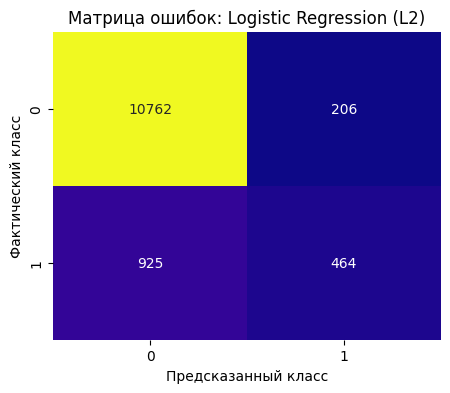

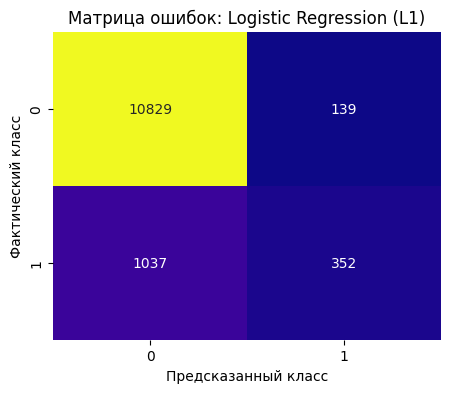

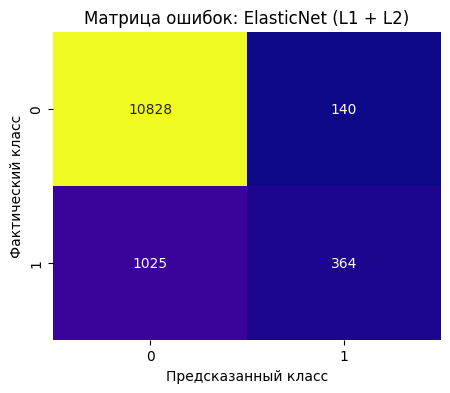

,Accuracy,Precision,Recall,F1
Logistic Regression (L2),0.9085,0.6925,0.3341,0.4507
Logistic Regression (L1),0.9048,0.7169,0.2534,0.3745
ElasticNet (L1 + L2),0.9057,0.7222,0.2621,0.3846


In [71]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

metrics_log = {}
prediction_log = {}

for name, model in models_log.items():
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    metrics_log[name] = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1}
    prediction_log[name] = (y_pred)

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm,
                annot=True,
                fmt='d',
                cmap='plasma',
                cbar=False)
    plt.title(f'Матрица ошибок: {name}')
    plt.xlabel('Предсказанный класс')
    plt.ylabel('Фактический класс')
    plt.show()

results_data3 = pd.DataFrame(metrics_log).T
display(results_data3.round(4))

- **Шаг 6**: Визуализируйте ROC-кривые для всех моделей и вычислите AUC для оценки.
  - Используйте `roc_curve` и `auc` из `sklearn.metrics` для построения и расчёта.
  - Постройте все ROC-кривые на одном графике для наглядного сравнения.



AUC (Logistic Regression (L2)): 0.9322
AUC (Logistic Regression (L1)): 0.9254
AUC (ElasticNet (L1 + L2)): 0.9254


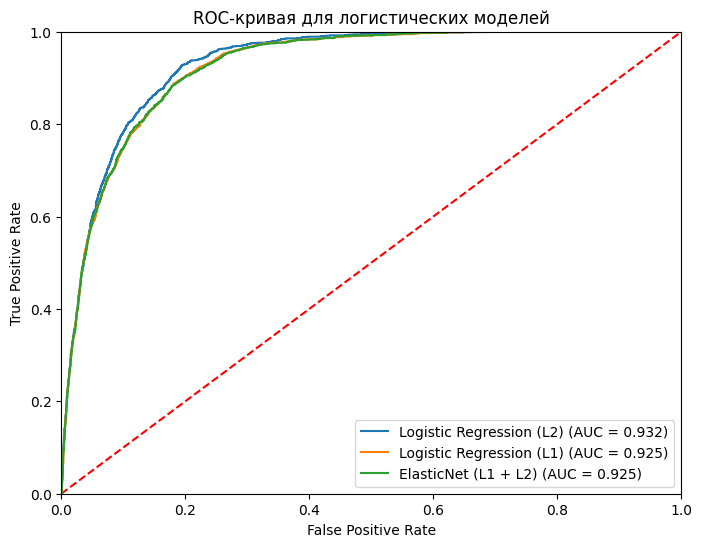

In [72]:
from sklearn.metrics import roc_curve, auc

pred_proba = {}
for name, model in models_log.items():
    pred_proba[name] = model.predict_proba(X_test)[:, 1]

real3 = y_test.values
plt.figure(figsize=(8,6))
plt.plot([0,1], [0,1], 'r--')

for name in pred_proba:
    fpr, tpr, thresholds = roc_curve(y_test, pred_proba[name])
    auc_sc = auc(fpr, tpr)
    print(f'AUC ({name}): {auc_sc:.4f}')
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_sc:.3f})')

plt.xlim([0,1])
plt.ylim([0,1])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая для логистических моделей')
plt.legend(loc='lower right')
plt.show()

- **Шаг 7**: **Сравните все модели между собой по целевым метрикам (Accuracy, Precision, Recall, F1, AUC)**:
  - Создайте сводную таблицу с метриками для всех моделей.
  - Определите лучшую модель и выведите для неё все метрики, оптимальные гиперпараметры и матрицу ошибок.

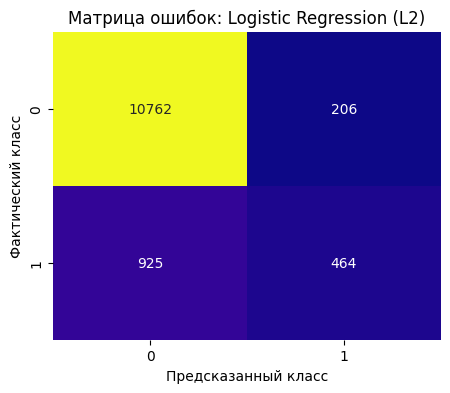

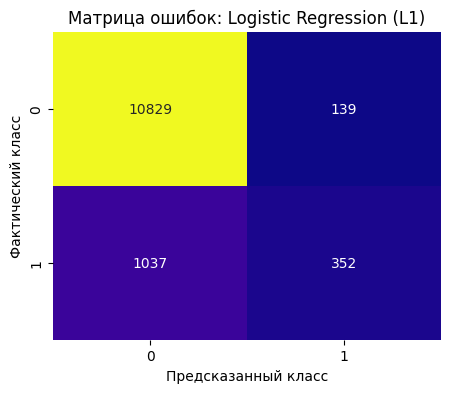

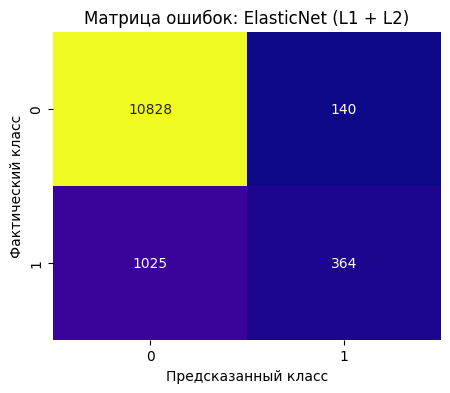

,Accuracy,Precision,Recall,F1
Logistic Regression (L2),0.9085,0.6925,0.3341,0.4507
Logistic Regression (L1),0.9048,0.7169,0.2534,0.3745
ElasticNet (L1 + L2),0.9057,0.7222,0.2621,0.3846


In [73]:
import sklearn.metrics
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

#проблема - numpy.ndarray' object is not callable (хотя у меня нет глобальных переменных-массивов) решена так:
if 'confusion_matrix' in globals() and not callable(globals()['confusion_matrix']):
    del confusion_matrix

metrics_log = {}
prediction_log = {}

for name, model in models_log.items():
    y_pred = model.predict(X_test)

    acc = sklearn.metrics.accuracy_score(y_test, y_pred)
    prec = sklearn.metrics.precision_score(y_test, y_pred, zero_division=0)
    rec = sklearn.metrics.recall_score(y_test, y_pred, zero_division=0)
    f1 = sklearn.metrics.f1_score(y_test, y_pred, zero_division=0)

    metrics_log[name] = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1}
    prediction_log[name] = y_pred

    cm = sklearn.metrics.confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm,
                annot=True,
                fmt='d',
                cmap='plasma',
                cbar=False)

    plt.title(f'Матрица ошибок: {name}')
    plt.xlabel('Предсказанный класс')
    plt.ylabel('Фактический класс')
    plt.show()

results_data3 = pd.DataFrame(metrics_log).T
display(results_data3.round(4))